# Lifting accuracy — PEDV (tblastn, 2 references)

**Denominator (truth-based):** mẫu số mỗi gene = record có gene đó trong truth (align `ref_name`). Buckets: `exact / coord_only / failed`. `coord` = không-exact + IoU≥0.90 + codon hợp lệ. Ca name-gap tách sang `extra_predictions_without_truth`.

## Inputs & setup

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
for c in [ROOT, *ROOT.parents]:
    if (c / "app" / "src").exists():
        ROOT = c
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import importlib
import app.validation._shared.validation_utils as _vu
importlib.reload(_vu)   # nạp lại nếu vừa sửa validation_utils (khỏi restart kernel)
from app.validation._shared.validation_utils import (
    run_lifting_accuracy, run_tblastn_against_truth, load_reference_bundle,
    build_truth_presence, attach_ref_lengths, summarize_per_gene, summarize_overall,
    adjudicate_failures,
)

DATA = ROOT / "app" / "data"
UNIT_DIR = ROOT / "app" / "validation" / "02_lifting_accuracy"
RUN_FULL = False


In [2]:
QUERY = DATA / "PED" / "PED_100seqs.gb"
OUT = UNIT_DIR / "outputs" / "ped"
OUT.mkdir(parents=True, exist_ok=True)

## Run — mỗi reference một lần

In [3]:
frames_pred, frames_gene = [], []
for label, ref in {"ref_1": DATA / "PED" / "PED_ref_1.gb", "ref_2": DATA / "PED" / "PED_ref_2.gb"}.items():
    pp, pg, ov, tp, rm = run_lifting_accuracy("ped", ref, QUERY, OUT / label, progress=True)
    pp["ref"] = label; pg["ref"] = label
    frames_pred.append(pp); frames_gene.append(pg)
per_pred = pd.concat(frames_pred, ignore_index=True)
per_gene = pd.concat(frames_gene, ignore_index=True)
overall = summarize_overall(per_gene, group_col="ref")
per_pred.to_csv(OUT / "tblastn_vs_truth.tsv", sep="\t", index=False)
overall

tblastn  ped:   0%|          | 0/100 [00:00<?, ?rec/s]

tblastn  ped:   0%|          | 0/100 [00:00<?, ?rec/s]

,ref,total,exact,coord_only,coord_correct,failed,no_hit,exact_pct,coord_only_pct,failed_pct,accuracy_pct
0,ref_1,505,500,4,504,1,0,99.01,0.79,0.2,99.8
1,ref_2,505,497,7,504,1,0,98.42,1.39,0.2,99.8
2,ALL,1010,997,11,1008,2,0,98.71,1.09,0.2,99.8


## Per-gene accuracy theo reference

In [4]:
cols = ["ref", "gene", "total", "exact", "coord_only", "failed", "no_hit", "accuracy_pct"]
per_gene[cols]

,ref,gene,total,exact,coord_only,failed,no_hit,accuracy_pct
0,ref_1,ORF1a,17,17,0,0,0,100.0
1,ref_1,ORF1b,8,4,3,1,0,87.5
2,ref_1,S,97,96,1,0,0,100.0
3,ref_1,ORF3,92,92,0,0,0,100.0
4,ref_1,E,97,97,0,0,0,100.0
5,ref_1,M,97,97,0,0,0,100.0
6,ref_1,N,97,97,0,0,0,100.0
7,ref_2,ORF1a,17,17,0,0,0,100.0
8,ref_2,ORF1b,8,1,6,1,0,87.5
9,ref_2,S,97,96,1,0,0,100.0


### Fig 1 — bucket theo gene

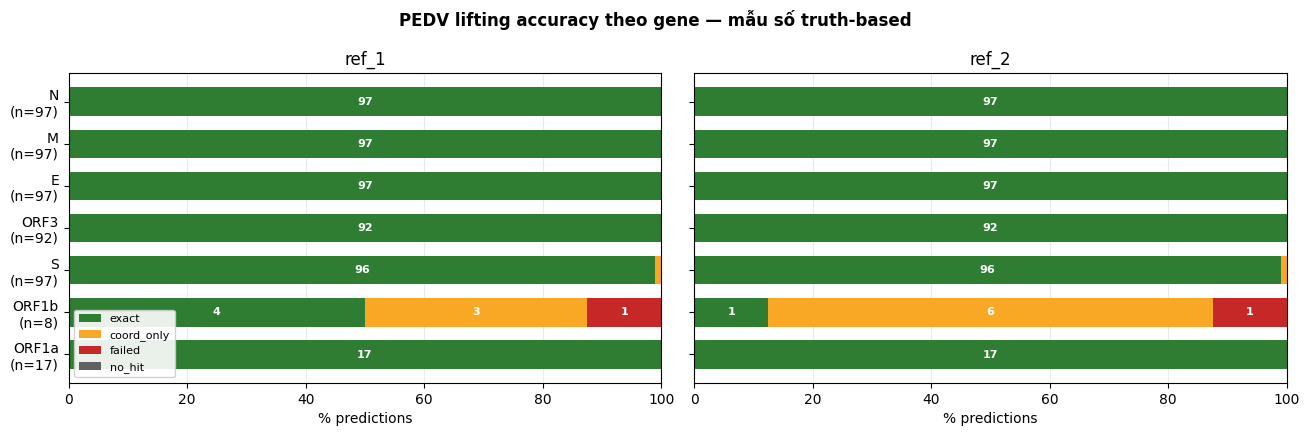

In [5]:
# Fig 1 — phân bố bucket theo gene (chuẩn hóa %, n ghi ở đầu thanh)
refs = sorted(per_gene["ref"].unique())
fig, axes = plt.subplots(1, len(refs), figsize=(6.6 * len(refs), 4.4), sharey=True)
axes = axes if len(refs) > 1 else [axes]
buckets = [("exact", "#2e7d32"), ("coord_only", "#f9a825"), ("failed", "#c62828"), ("no_hit", "#616161")]

for ax, rf in zip(axes, refs):
    d = per_gene[per_gene["ref"] == rf].set_index("gene")
    genes = list(d.index)
    labels = [f"{g}\n(n={t:.0f})" for g, t in zip(genes, d["total"])]
    left = [0.0] * len(genes)
    for name, colour in buckets:
        vals = (d[name] / d["total"] * 100).tolist()
        ax.barh(labels, vals, left=left, color=colour, label=name, height=0.68)
        for i, v in enumerate(vals):
            if v >= 4:
                ax.text(left[i] + v / 2, i, f"{d[name].iloc[i]:.0f}", ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold")
        left = [a + b for a, b in zip(left, vals)]
    ax.set_xlim(0, 100); ax.invert_yaxis(); ax.set_title(rf); ax.set_xlabel("% predictions")
    ax.grid(axis="x", alpha=0.25); ax.set_axisbelow(True)

axes[0].legend(loc="lower left", fontsize=8, framealpha=0.9)
fig.suptitle("PEDV lifting accuracy theo gene — mẫu số truth-based", fontweight="bold")
fig.tight_layout(); plt.show()

# ── Coord-only (đúng vùng nhưng lệch biên) ──

Thống kê theo gene, rồi breakdown từng gene bên dưới.

In [6]:
coord_stat = per_gene[per_gene["coord_only"] > 0][["gene", "total", "coord_only", "coord_only_pct"]]\
    .sort_values("coord_only", ascending=False)
coord_only_cases = per_pred[per_pred["coord_correct"].fillna(False) & ~per_pred["exact_match"].fillna(False)].copy()
coord_only_cases.to_csv(OUT / "coord_only_cases.tsv", sep="\t", index=False)
coord_stat

,gene,total,coord_only,coord_only_pct
8,ORF1b,8,6,75.00
1,ORF1b,8,3,37.50
2,S,97,1,1.03
9,S,97,1,1.03


### coord · thống kê theo gene

In [7]:
other = coord_only_cases[~coord_only_cases["ref_name"].isin([])]
other.groupby("ref_name").size().reset_index(name="cases") if len(other) else "— không còn gene khác —"

,ref_name,cases
0,ORF1b,9
1,S,2


### Fig 2 — ORF1b start vs end

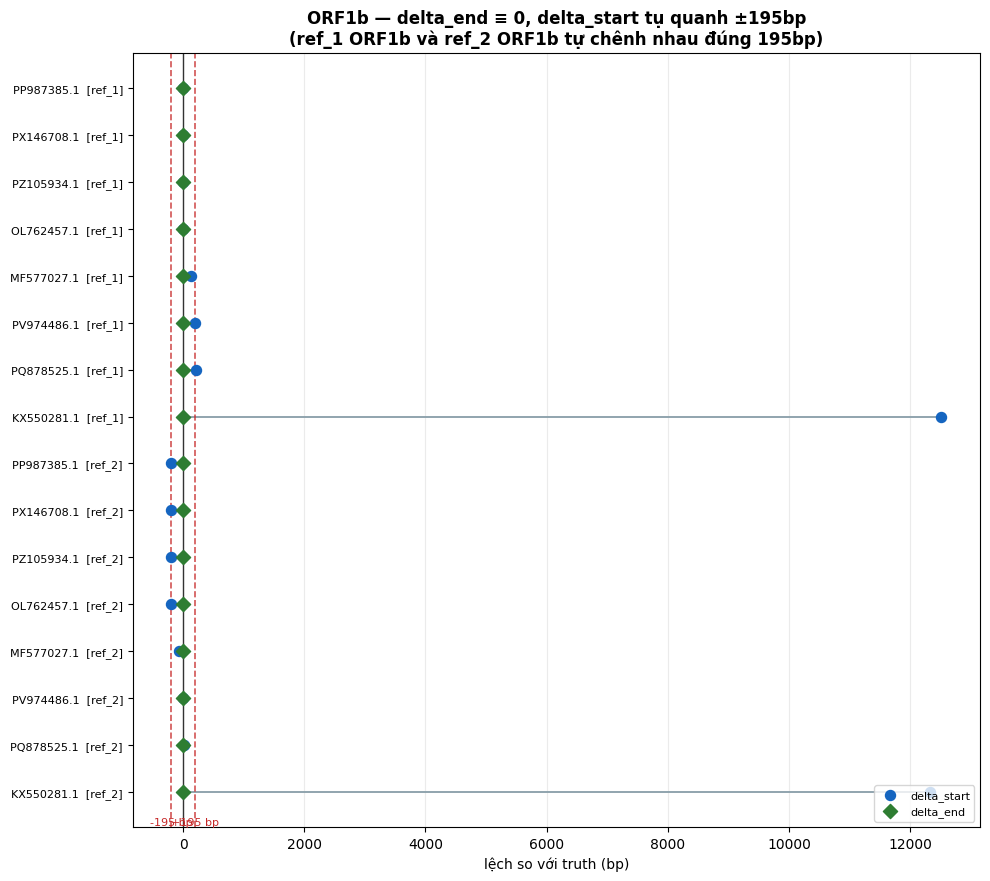

In [8]:
# Fig 2 — ORF1b: điểm bắt đầu là quy ước, điểm kết thúc thì không
o = per_pred[(per_pred["ref_name"] == "ORF1b") & per_pred["name_match"].fillna(False)].copy()
o = o.dropna(subset=["delta_start", "delta_end"]).sort_values(["ref", "delta_start"])
lab = [f"{r.record_id}  [{r.ref}]" for r in o.itertuples()]
y = range(len(o))

fig, ax = plt.subplots(figsize=(10, 0.42 * len(o) + 2.2))
ax.hlines(list(y), 0, o["delta_start"], color="#90a4ae", lw=1.4, zorder=1)
ax.scatter(o["delta_start"], list(y), s=52, color="#1565c0", zorder=3, label="delta_start")
ax.scatter(o["delta_end"], list(y), s=52, marker="D", color="#2e7d32", zorder=3, label="delta_end")

# Hai reference tự bất đồng đúng bằng khoảng này -> đó là quy ước, không phải lỗi.
gap = int(abs(per_pred[per_pred.ref_name == "ORF1b"].groupby("ref")["ref_len"].first().diff().iloc[-1]))
for x in (-gap, gap):
    ax.axvline(x, color="#c62828", ls="--", lw=1.2, alpha=0.8)
    ax.text(x, len(o) - 0.3, f"{x:+d} bp", color="#c62828", fontsize=8, ha="center")
ax.axvline(0, color="#333", lw=1)

ax.set_yticks(list(y)); ax.set_yticklabels(lab, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("lệch so với truth (bp)"); ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="x", alpha=0.25); ax.set_axisbelow(True)
ax.set_title(f"ORF1b — delta_end ≡ 0, delta_start tụ quanh ±{gap}bp\n"
             f"(ref_1 ORF1b và ref_2 ORF1b tự chênh nhau đúng {gap}bp)", fontweight="bold")
fig.tight_layout(); plt.show()

### Giải thích coord-only

11 ca = **9 ORF1b + 2 S**, hai nguyên nhân hoàn toàn khác nhau.

#### ORF1b (9 ca / 6 record) — quy ước mốc đầu, không phải lỗi

`delta_end = 0` ở **cả 9 ca**: đuôi luôn đúng, chỉ mốc đầu lệch. ORF1b được dịch mã qua
**−1 ribosomal frameshift** từ ORF1a nên **không có start codon riêng** — không ribosome nào "bắt đầu"
ở đó, chúng đến bằng cách tuột khung. Vì vậy khai báo điểm đầu ở đâu là **quy ước thuần túy**.

Hai reference tự bất đồng đúng chỗ đó:

```
PED_ref_1:  ORF1a 293..12646   ORF1b 12811..20637   ->  HỞ 164 bp
PED_ref_2:  ORF1a 271..12624   ORF1b 12594..20615   ->  CHỒNG LẤN 31 bp
                                                        164 + 31 = 195
```

Và trên **cả 8 record** có ORF1b trong truth, `Δ(ref_2) − Δ(ref_1) = −195`, không sót một ca nào
(kể cả ca failed: +12518 → +12323). **Tool hoàn toàn nhất quán**; toàn bộ độ tản mát đến từ việc
lift theo quy ước của ref nào. Các lab khai 5 độ dài khác nhau cho cùng gene này:
`7446, 7827, 7962, 8022, 8037`.

Hệ quả cho cách đọc metric — **đáng đưa vào paper**: `ref_1` dài 7827bp nên trùng quy ước với 4 record
(4 exact / 3 coord); `ref_2` dài 8022bp nên chỉ trùng 1 record (1 exact / 6 coord). Nhưng
**accuracy của cả hai ref đều là 99.8%**. Với gene không có start codon, `exact_pct` đo **sự đồng thuận
quy ước** chứ không đo chất lượng lifting; chỉ metric dựa trên IoU mới phản ánh đúng năng lực tool.

Một ca khác bản chất: `PX146708.1` khai 7446bp với `coverage 0.9989`, `pred_len 7641` — record bị cụt,
không phải chuyện quy ước.

#### S (2 ca, cùng 1 record) — chủng tái tổ hợp đã được công bố

`MF577027.1` = **PEDV/Belgorod/dom/2008** (Nga), `delta_start −36`, `identity 59–60%` trong khi mọi
record khác đạt 97–100%. Đo trực tiếp bằng alignment toàn cục với cả hai reference:

| gene | %id vs ref_1 | %id vs ref_2 |
|---|---|---|
| **S** | **60.8%** | **61.0%** |
| M | 97.3% | 97.3% |
| N | 95.6% | 95.6% |

Backbone là PEDV bình thường, **chỉ riêng S phân kỳ** — chữ ký của tái tổ hợp. Y văn xác nhận: chủng này
giống PEDV 97% ở mức toàn genome nhưng spike chỉ ~66% giống các PEDV trên GenBank, với **hai điểm gãy
tái tổ hợp tại nt 20476 (trong ORF1B) và nt 24403 (trong S)**; major parent là **LZC (EF185992)**,
minor parent là SLO/JH-11/2015. Kiểm chứng lại bằng tọa độ của chính record: cả hai điểm gãy đều rơi
đúng vào ORF1B (12675..20636) và S (20633..24751).

**Đây là điểm mạnh chứ không phải điểm yếu của tool.** Dù protein chỉ giống 60%, lifting vẫn cho
`delta_end = 0` và **IoU 0.9913** → vẫn coord-correct. tblastn ở mức protein chịu được 40% phân kỳ mà
vẫn định vị gần như chính xác. Phần lệch 36bp ở đầu 5' là chỗ alignment bắt đầu rão.

Lưu ý tinh tế: ORF1b của chính record này **vẫn giữ 98.6% identity dù có điểm gãy nt 20476 nằm bên trong nó**
— vì major parent (LZC) cũng là PEDV. Tái tổ hợp giữa hai chủng cùng loài không gây phân kỳ; phân kỳ ở S
là do minor parent khác xa. Và ORF1b của nó lệch +135/−60 hoàn toàn do **quy ước** (record để hở 29bp
giữa ORF1a và ORF1b, so với 164bp hở của ref_1 và 31bp chồng của ref_2), **không** do tái tổ hợp.

Nguồn: [Archives of Virology — Molecular characteristics of a novel recombinant of PEDV](https://link.springer.com/article/10.1007/s00705-019-04166-4) ·
[Genome Announc. — Complete genome sequence of PEDV isolated in Belgorod, Russia, 2008 (PMC5637491)](https://pmc.ncbi.nlm.nih.gov/articles/PMC5637491/)

# ── Failed (trong truth nhưng không coord-correct) ──

Thống kê theo gene, rồi breakdown từng gene.

In [9]:
failed_stat = per_gene[per_gene["failed"] > 0][["gene", "total", "failed", "failed_pct", "no_hit"]]\
    .sort_values("failed", ascending=False)
failed_cases = per_pred[per_pred["name_match"].fillna(False) & ~per_pred["coord_correct"].fillna(False)].copy()
failed_cases.to_csv(OUT / "failed_cases.tsv", sep="\t", index=False)
failed_stat

,gene,total,failed,failed_pct,no_hit
1,ORF1b,8,1,12.5,0
8,ORF1b,8,1,12.5,0


### failed · thống kê theo gene

In [10]:
other = failed_cases[~failed_cases["ref_name"].isin([])]
other.groupby("ref_name").size().reset_index(name="cases") if len(other) else "— không còn gene khác —"

,ref_name,cases
0,ORF1b,2


### Fig 3 — bản đồ genome ca failed

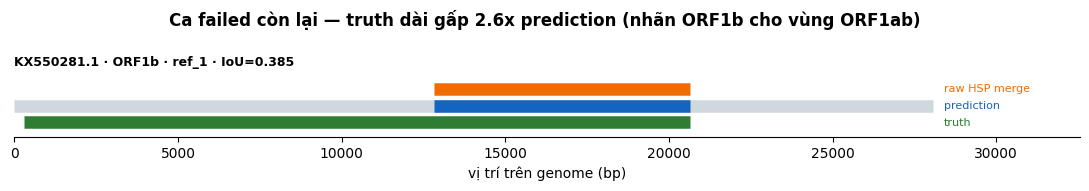

In [11]:
# Fig 3 — bản đồ genome các ca failed: span HSP thô vs prediction vs truth
from Bio import SeqIO
glen = {r.id: len(r.seq) for r in SeqIO.parse(QUERY, "genbank")}

fc = per_pred[per_pred["name_match"].fillna(False) & ~per_pred["coord_correct"].fillna(False)]
fc = fc.drop_duplicates(subset=["record_id", "ref_name"]).sort_values(["record_id"])

fig, axes = plt.subplots(len(fc), 1, figsize=(11, 1.9 * len(fc)))
axes = axes if len(fc) > 1 else [axes]
for ax, row in zip(axes, fc.itertuples()):
    L = glen.get(row.record_id, max(row.truth_end or 0, row.pred_end or 0))
    ax.hlines(0, 0, L, color="#cfd8dc", lw=9, zorder=1)   # genome
    bars = [
        ("raw HSP merge", row.raw_start, row.raw_end, "#ef6c00", 1.0),
        ("prediction",    row.pred_start, row.pred_end, "#1565c0", 0.0),
        ("truth",         row.truth_start, row.truth_end, "#2e7d32", -1.0),
    ]
    for name, s, e, colour, yy in bars:
        if s is None or e is None or (isinstance(s, float) and s != s):
            continue
        ax.hlines(yy, s, e, color=colour, lw=9, zorder=3)
        ax.text(L * 1.012, yy, name, va="center", fontsize=8, color=colour)
    ax.set_xlim(0, L * 1.16); ax.set_ylim(-1.9, 1.9); ax.set_yticks([])
    ax.set_title(f"{row.record_id} · {row.ref_name} · {row.ref} · IoU={row.iou:.3f}",
                 fontsize=9, loc="left", fontweight="bold")
    ax.spines[["top", "right", "left"]].set_visible(False)
axes[-1].set_xlabel("vị trí trên genome (bp)")
fig.suptitle("Ca failed còn lại — truth dài gấp 2.6x prediction (nhãn ORF1b cho vùng ORF1ab)", fontweight="bold")
fig.tight_layout(); plt.show()

### Giải thích failed

Sau khi thêm bộ lọc mảnh khớp lạc dòng vào `merge_hsps`, **chỉ còn 2 ca failed**, và cả hai đều
không thuộc trách nhiệm của tool — bảng adjudication bên dưới giờ chỉ còn nhãn `ref_truth`.

**Còn lại: KX550281.1 ORF1b — GenBank ghi sai tên, tool đúng.**

```
KX550281.1:  CDS  293..20637  (20345bp)  đặt tên "ORF1b"    ← sai
OR085251.1:  CDS  417..20761  (20345bp)  đặt tên "ORF1ab"   ← đúng
PV536098.1:  CDS  453..20797  (20345bp)  đặt tên "ORF1ab"   ← đúng
```

Cùng y hệt 20345bp = trọn replicase, nhưng KX550281 gọi là ORF1b. Tool dự đoán ORF1b = `12811..20637`
(7827bp) — chính xác. Nó bị chấm fail chỉ vì name-match kéo prediction đi so với một truth dài gấp 2.6 lần
→ IoU 0.38. Hai record đối chứng cùng độ dài mà đặt tên đúng khiến kết luận này chứng minh được.

---

**Đã sửa: OR085251.1 (N) và PV536098.1 (S) — lỗi gộp mảnh trong `merge_hsps`.**

| record | gene | span HSP thô | ref_len | truth |
|---|---|---|---|---|
| OR085251.1 | N | `61..27825` (**27765bp**) | 1326 | 26503..27828 |
| PV536098.1 | S | `2..24951` (**24950bp**) | 4161 | 20794..24954 |

`raw_end` đúng, nhưng `raw_start` bị kéo về đầu genome: một mảnh khớp ngẫu nhiên ở vùng 5' bị gộp chung với
mảnh thật cách đó ~26kb, rồi validator quét từ đó gặp stop codon đầu tiên nên cắt cụt còn 93bp / 165bp.

Nguyên nhân: `merge_hsps` gộp bằng `min(start)`/`max(end)` trên mọi mảnh cùng chiều, **không kiểm tra khoảng
cách**. Và `coverage` được tính trên **trục protein** (số aa được phủ) chứ không phải span genome, nên mảnh
thật đã phủ trọn protein vẫn cho `coverage = 1.0` — ngưỡng coverage không bao giờ chặn được ca này.

**Cách sửa (generic, leakage-free).** Mỗi mảnh khai một "điểm gốc" = `vị_trí_genome − (aa_trên_protein − 1) × 3`.
Các mảnh thật của cùng một gene đồng thuận về điểm gốc; mảnh lạc thì không. Gom cụm theo điểm gốc với dung sai
`max(150bp, 10% × ref_len)`, giữ cụm phủ được nhiều aa ref nhất, rồi mới gộp. Thêm chốt chặn span `≤ ref_len × 2`.
Chỉ dùng tọa độ mảnh + độ dài protein ref + bit score — **không đụng tới truth**.

Ghi chú: gene bắc qua điểm trượt khung (ORF1ab) làm điểm gốc lệch đúng 1bp, nằm sâu trong dung sai nên không
bị tách nhầm. `PV536098.1` được GenBank gắn nhãn `UNVERIFIED_ASMBLY` — đúng loại record có artifact lắp ráp
ở đầu 5' mà bộ lọc này sinh ra để chặn.

**Kết quả:** N và S lên 100% trên cả hai reference; failed 6 → 2; accuracy 99.41% → 99.80%;
`coord_only` giữ nguyên 11 (không ca exact nào bị ảnh hưởng).

# ── No-hit ──

Gene tblastn không ra hit (coverage/identity thấp).

In [12]:
no_hit_cases = per_pred[per_pred["status"].fillna("").eq("no_hit")].copy()
no_hit_cases[["record_id", "ref_name", "coverage", "identity", "status"]]

,record_id,ref_name,coverage,identity,status


# ── Extra predictions without truth (name-gap / granularity) ──

In [13]:
extra_cases = per_pred[~per_pred["name_match"].fillna(False)].copy()
extra_cases.to_csv(OUT / "extra_without_truth_cases.tsv", sep="\t", index=False)
extra_cases.groupby("ref_name").size().reset_index(name="cases")

,ref_name,cases
0,E,2
1,M,2
2,N,2
3,ORF1a,162
4,ORF1b,180
5,ORF3,12
6,S,2


**Vì sao ORF1a/ORF1b có nhiều "extra" đến vậy:** 83/100 record annotate replicase thành **một** CDS
`ORF1ab`, trong khi reference tách thành ORF1a + ORF1b. Nên hai prediction đó không có truth đối ứng.
Đây chính là **standardization đang chạy đúng** — gom granularity không nhất quán về một convention duy nhất,
giống hệt câu chuyện 2A/VP1 ở FMDV. Không phải thứ cần "sửa".

# ── Failure breakdown (adjudication generic) ──

`blame = ref_truth / tool / review` chỉ bằng length-delta (không hardcode gene): pred==ref & truth khác → ref_truth; truth==ref & pred khác → tool; pred ngắn hơn cả hai + cov thấp → tool; no-hit → tool; còn lại → review.

In [14]:
failed = per_pred[per_pred["name_match"].fillna(False) & ~per_pred["coord_correct"].fillna(False)].copy()
adj = adjudicate_failures(failed)
adj.to_csv(OUT / "failure_adjudication.tsv", sep="\t", index=False)
adj.groupby(["blame", "cause"]).size().reset_index(name="cases").sort_values("cases", ascending=False)

,blame,cause,cases
0,ref_truth,ref_query_boundary_convention,2


## Theo gene (tool vs ref_truth vs review)

In [15]:
adj.groupby(["ref_name", "blame"]).size().unstack(fill_value=0)

blame,ref_truth
ref_name,
ORF1b,2


# ── Tóm tắt PEDV ──

## Số liệu

100 record × 2 reference = **1010 prediction** đánh giá được (mẫu số truth-based).

| | trước fix | **sau fix** |
|---|---|---|
| exact | 993 | **997** |
| coord-only | 11 | **11** |
| failed | 6 | **2** |
| no-hit | 0 | **0** |
| **accuracy** | 99.41% | **99.80%** |
| blame `tool` | 3 | **0** |

Per-gene (giống nhau ở cả hai ref trừ ORF1b): `ORF1a, ORF3, E, M, N, S` = **100%**;
`ORF1b` = 87.5%. Sau khi sửa, **không còn failure nào quy trách nhiệm cho tool**.

## 2 ca failed — đều là 1 record, GenBank ghi sai nhãn

| record | gene | ref_1 | ref_2 | IoU |
|---|---|---|---|---|
| `KX550281.1` | ORF1b | Δ +12518 | Δ +12323 | 0.38 / 0.39 |

Record khai `ORF1b = 293..20637 (20345bp)` — nhưng 20345bp là **trọn replicase**, tức `ORF1ab`.
Hai record khác (`OR085251.1`, `PV536098.1`) có **y hệt 20345bp** mà gọi đúng là `ORF1ab`, nên
kết luận này chứng minh được. Tool dự đoán ORF1b = `12811..20637` (7827bp) — **đúng**; nó bị chấm
fail chỉ vì bị so với một truth dài gấp 2.6 lần. Tool không sửa được lỗi nhãn của người submit.

## 11 ca coord-only — hai nguyên nhân

### ORF1b: 9 ca / 6 record — quy ước mốc đầu

| record | truth_len | Δ ref_1 | Δ ref_2 |
|---|---|---|---|
| `PX146708.1` | 7446 | exact | −195 |
| `OL762457.1` | 7827 | exact | −195 |
| `PP987385.1` | 7827 | exact | −195 |
| `PZ105934.1` | 7827 | exact | −195 |
| `MF577027.1` | 7962 | +135 | −60 |
| `PV974486.1` | 8022 | +195 | exact |
| `PQ878525.1` | 8037 | +210 | +15 |

`delta_end = 0` ở **cả 9 ca** — đuôi luôn đúng, chỉ mốc đầu lệch. ORF1b dịch mã qua **−1 ribosomal
frameshift** nên **không có start codon riêng**; khai điểm đầu ở đâu là quy ước tùy lab. Các lab khai
5 độ dài khác nhau cho cùng gene này.

Hai reference cũng tự bất đồng đúng chỗ đó: `ref_1` để **hở 164bp** sau ORF1a, `ref_2` cho **chồng lấn
31bp** → chênh **195bp**. Và `Δ(ref_2) − Δ(ref_1) = −195` trên **toàn bộ 8 record, không ngoại lệ**
(kể cả ca failed: +12518 → +12323) ⇒ **tool hoàn toàn nhất quán**, mọi tản mát đến từ quy ước của ref.

Ngoại lệ về bản chất: `PX146708.1` khai 7446bp với `coverage 0.9989` — record **bị cụt**, không phải
chuyện quy ước.

### S: 2 ca / 1 record — chủng tái tổ hợp đã công bố

| record | Δ start | Δ end | identity | IoU |
|---|---|---|---|---|
| `MF577027.1` | −36 | 0 | 59–60% | 0.9913 |

`PEDV/Belgorod/dom/2008` (Nga). Đo bằng alignment toàn cục: **S 60.8%** nhưng **M 97.3%, N 95.6%** —
backbone PEDV bình thường, **chỉ S phân kỳ** ⇒ tái tổ hợp. Y văn xác nhận: toàn genome giống PEDV 97%,
spike chỉ ~66%, hai điểm gãy tại **nt 20476 (trong ORF1B)** và **nt 24403 (trong S)**; major parent là
**LZC (EF185992)**.

**Đây là điểm mạnh của tool, không phải điểm yếu:** protein chỉ giống 60% mà lifting vẫn cho
`delta_end = 0` và **IoU 0.9913**. Lệch 36bp ở đầu 5' là chỗ alignment rão.

## Bug đã tìm ra và sửa

`merge_hsps` gộp mảnh HSP bằng `min(start)`/`max(end)`, **không kiểm tra khoảng cách**. Một mảnh khớp
ngẫu nhiên ở vùng 5' bị gộp với mảnh thật cách ~26kb → span gấp 21× chiều dài gene → validator cắt cụt
còn 93bp/165bp. Ngưỡng `coverage` không chặn được vì coverage đo trên **trục protein** (mảnh thật đã phủ
trọn → 1.0) còn lỗi nằm trên **trục genome**.

```
OR085251.1 N :  raw 61..27825    → pred    61..153   IoU 0.000  ❌
             :  raw 26503..27825 → pred 26503..27828 IoU 1.000  ✅
PV536098.1 S :  raw 2..24951     → pred     2..166   IoU 0.000  ❌
             :  raw 20794..24951 → pred 20794..24954 IoU 1.000  ✅
```

**Cách sửa (generic, leakage-free):** mỗi mảnh khai một điểm gốc `= vị_trí_genome − (aa_trên_protein − 1) × 3`.
Mảnh thật của cùng gene đồng thuận, mảnh lạc thì không. Gom cụm với dung sai `max(150bp, 10% × ref_len)`,
giữ cụm phủ nhiều aa ref nhất, kèm chốt chặn span `≤ ref_len × 2`. Chỉ dùng tọa độ mảnh + độ dài protein
ref + bit score — **không đụng truth, không hardcode theo virus/gene**.

## Ba luận điểm cho paper

**`exact_pct` không đo chất lượng lifting với gene không có start codon.** Cùng tool, cùng query:
`ref_1` cho 4 exact / 3 coord, `ref_2` cho 1 exact / 6 coord — chỉ vì hai ref chọn hai quy ước. Nhưng
accuracy theo IoU **giống hệt nhau: 99.8%**.

**"Extra predictions" là standardization đang hoạt động.** 83/100 record annotate replicase thành **một**
CDS `ORF1ab` trong khi reference tách ORF1a + ORF1b, sinh ra 162 + 180 prediction không có truth đối ứng.
Đó chính là việc gom granularity bất nhất về một convention — mục đích tồn tại của tool.

**Dùng nhiều reference khác quy ước là một thiết kế validation có giá trị.** Chênh lệch 195bp không phải
nhiễu mà là **phép đo trực tiếp mức bất nhất của annotation GenBank**, và nó tách được "tool sai" khỏi
"quy ước khác" theo cách một reference đơn lẻ không làm được.

Nguồn: [Archives of Virology — novel recombinant PEDV](https://link.springer.com/article/10.1007/s00705-019-04166-4) ·
[Genome Announc. — PEDV Belgorod Russia 2008 (PMC5637491)](https://pmc.ncbi.nlm.nih.gov/articles/PMC5637491/)